In [2]:
from pathlib import Path
import sys
import json
import uuid
from datetime import datetime
import os

ROOT_DIR = Path.cwd().parent.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
print(f'Base directory -> {ROOT_DIR}')

from src.db_conn import DatabaseConnection
from config.settings import (
    DATA_DIR,
    MODELS_DIR,
    FORECAST_DIR
)

import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


Base directory -> /Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


/Users/angelvelasco/envs/urvet_projects/lib/python3.13/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/angelvelasco/envs/urvet_projects/lib/python3.13/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI


In [2]:
master = pd.read_csv(f'{DATA_DIR}/master.csv')

display(master)

,sale_date,net_price,non_work_day,is_month_end,close_month_zone
0,2024-01-02,"719,422.63",0,0,0
1,2024-01-03,"992,292.59",0,0,0
2,2024-01-04,"802,011.48",0,0,0
3,2024-01-05,"484,853.02",0,0,0
4,2024-01-06,"60,058.17",0,0,0
...,...,...,...,...,...
860,2026-05-11,"1,790,415.58",0,0,0
861,2026-05-12,"2,139,962.69",0,0,0
862,2026-05-13,"1,245,428.49",0,0,1
863,2026-05-14,"1,656,746.25",0,0,1


In [3]:
#definimos train, test, validation
train_cutoff = '2026-04-30'
validation_start = '2026-05-01'
validation_end = '2026-05-31'

In [4]:
#seoaramos la variable target de las exogenas
y = master['net_price']
X = master[['non_work_day', 'is_month_end', 'close_month_zone']]

display(X)
display(y)

,non_work_day,is_month_end,close_month_zone
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
...,...,...,...
860,0,0,0
861,0,0,0
862,0,0,1
863,0,0,1


0       719,422.63
1       992,292.59
2       802,011.48
3       484,853.02
4        60,058.17
          ...     
860   1,790,415.58
861   2,139,962.69
862   1,245,428.49
863   1,656,746.25
864     646,434.79
Name: net_price, Length: 865, dtype: float64

In [5]:
y.index = pd.to_datetime(master['sale_date'])
X.index = pd.to_datetime(master['sale_date'])
#split de datos
y_train = y[:train_cutoff]
y_val   = y[validation_start:validation_end]

X_train = X[:train_cutoff]
X_val   = X[validation_start:validation_end]

display(X_train)
display(y_train)

,non_work_day,is_month_end,close_month_zone
sale_date,,,
2024-01-02,0,0,0
2024-01-03,0,0,0
2024-01-04,0,0,0
2024-01-05,0,0,0
2024-01-06,0,0,0
...,...,...,...
2026-04-26,0,0,0
2026-04-27,0,0,0
2026-04-28,0,0,1


sale_date
2024-01-02     719,422.63
2024-01-03     992,292.59
2024-01-04     802,011.48
2024-01-05     484,853.02
2024-01-06      60,058.17
                 ...     
2026-04-26           0.00
2026-04-27   1,635,003.20
2026-04-28   2,226,883.72
2026-04-29   1,791,020.57
2026-04-30   3,330,617.51
Name: net_price, Length: 850, dtype: float64

In [6]:
def save_metadata(*,
                  order: list = [0,0,0],
                  seasonal_order: list = [0,0,0,7],
                  enforce_stationarity: bool = False,
                  enforce_invertibility: bool = False,
                  fit_obj,
                  file_path: str = f'{MODELS_DIR}/sarimax.json',
                  model_id: str = None,
                  ) -> dict:

    try:
        start_date = fit_obj.model.data.dates[0].strftime('%Y-%m-%d')
        end_date = fit_obj.model.data.dates[-1].strftime('%Y-%m-%d')
    except (AttributeError, TypeError):
        start_date = str(fit_obj.model.data.row_labels[0])
        end_date = str(fit_obj.model.data.row_labels[-1])

    model_metadata = {
        "train_period": {
            "start_date": start_date,
            "end_date": end_date
        },
        "hyperparameters": {
            "order": order,
            "seasonal_order": seasonal_order,
            "enforce_stationarity": enforce_stationarity,
            "enforce_invertibility": enforce_invertibility
        },
        "metrics": {
            "aic": float(fit_obj.aic),
            "bic": float(fit_obj.bic),
            "log_likelihood": float(fit_obj.llf),
            "nobs": int(fit_obj.nobs)
        },
        "coeficientes": fit_obj.params.to_dict()
    }

    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            try:
                data_historica = json.load(f)
            except json.JSONDecodeError:
                data_historica = {}
    else:
        data_historica = {}

    if model_id is None:
        model_id = f'{datetime.now().date()}_{uuid.uuid4()}'

    data_historica[model_id] = model_metadata

    with open(file_path, "w") as f:
        json.dump(data_historica, f, indent=4)

    print(f'Metadata saved for model: {model_id}\n')
    return model_metadata

In [7]:
#primeras pruebas con parámetros
p_1=1
d_1=0 #obtenido gracia a ADF
q_1=1

P_1=1
D_1=0
Q_1=1

order_1 = (p_1, d_1, q_1)

s=7 #estacionalidad semanal ya comprobada
s_order_1 = (P_1, D_1, Q_1,s)
model_1 = SARIMAX(
    y_train,
    exog=X_train,
    order=order_1,
    seasonal_order=s_order_1,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_1 = model_1.fit(disp=False)

print(fit_res_1.summary())

meta_1 = save_metadata(
    order=list(order_1),
    seasonal_order=list(s_order_1),
    fit_obj=fit_res_1,
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -11910.820
Date:                           Wed, 20 May 2026   AIC                          23837.639
Time:                                   05:55:47   BIC                          23875.225
Sample:                               01-02-2024   HQIC                         23852.069
                                    - 03-31-2026                                         
Covariance Type:                             opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
non_work_day      1309.9661   6766.240      0.194      0.846    -1.2e+04    1.46e+04
is_month_end      2.472e+

#### interpretación de resultados model_1

* Cierre Comercial.

    La variable `is_month_end` cuenta con un p-value perfecto de `0.000`. Esto revela que el último día laborable del mes es un fenómeno de facturación masiva aislado que aporta casi $2.5M extras sobre la tendencia base.

* El Efecto de la Zona de Cierre (`close_month_zone`).

    Mantiene un impacto sólido de +$1,512,000 pesos (`P>|z| = 0.000`) durante los dos días laborables previos al cierre. Esto demuestra un comportamiento escalonado: la última semana del mes arranca con un empuje de +$1.5M diarios y culmina con un clímax de +$2.4M en la última jornada útil.

* Warning [2].

    El aviso de inestabilidad en los errores estándar `condition number 1.36e+30` es muy alto. La causa matemática es la variable `non_work_day` (`P>|z| = 0.865`). Al incluir una bandera de días no laborales junto con un orden estacional de rezago 7 (`s=7`), se genera una redundancia estructural, ya que el componente autorregresivo estacional del modelo ya mapea y absorbe matemáticamente las caídas fijas de los fines de semana.

* Componente de promedio movil `ma.L1`.

    El parámetro de media móvil diaria tradicional arrojó un p-value de `0.816`. Esto significa que los errores del día anterior no tienen un impacto arrastrable en las ventas del día de hoy, haciendo que este parámetro sea puro ruido dentro del algoritmo.

#### Parámetrso para el siguiente modelo (Model 2)

Para limpiar las alertas matemáticas, reducir el sobreajuste y estabilizar los errores estándar antes de la exportación final, se propone transicionar hacia la configuración `SARIMAX(1, 0, 0)x(1, 0, 1, 7)`:

* Parte No Estacional: `order=(1, 0, 0)`
* $p = 1$ (Autorregresivo - AR): Mantenemos un rezago diario de corto plazo. Aunque en el primer modelo marcó un p-value de `0.065` (ligeramente arriba del umbral del 5%), es altamente probable que se estabilice y vuelva significativo al remover el ruido que provocaba la interacción con el componente MA.
* $d = 0$ (Diferenciación): Se mantiene en cero fijo, respaldado por la prueba de Dickey-Fuller Aumentada que demostró la estacionariedad de la serie tras la imputación de anomalías.
* $q = 0$ (Media Móvil - MA): Se reduce a cero. Al comprobarse que `ma.L1` no es estadísticamente significativo (`0.816`), removerlo simplifica la matriz de covarianza y ayuda a mitigar la singularidad del modelo.


* Parte Estacional: `seasonal_order=(1, 0, 1, 7)`
* Se preserva intacto debido a la significancia perfecta (`0.000`) de los rezagos estacionales de 7 días. El modelo requiere mantener tanto el término autorregresivo estacional ($P=1$) como la media móvil estacional ($Q=1$) para poder replicar matemáticamente los valles fijos de los domingos.

In [8]:
#eliminacion de non_work_day
X_optimized = X_train[['is_month_end', 'close_month_zone']]

display(X_optimized)

,is_month_end,close_month_zone
sale_date,,
2024-01-02,0,0
2024-01-03,0,0
2024-01-04,0,0
2024-01-05,0,0
2024-01-06,0,0
...,...,...
2026-03-27,0,1
2026-03-28,0,0
2026-03-29,0,0


In [9]:
p_2, d_2, q_2 = 1, 0, 0
P_2, D_2, Q_2, s_2 = 1, 0, 1, 7

order_2 = (p_2, d_2, q_2)
s_order_2 = (P_2, D_2, Q_2, s_2)

model_2 = SARIMAX(
    y_train,
    exog=X_optimized,
    order=order_2,
    seasonal_order=s_order_2,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_2 = model_2.fit(disp=False)
print(fit_res_2.summary())


meta_2 = save_metadata(
    order=list(order_2),
    seasonal_order=list(s_order_2),
    fit_obj=fit_res_2,
)


/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood              -11924.855
Date:                             Wed, 20 May 2026   AIC                          23861.709
Time:                                     05:55:47   BIC                          23889.906
Sample:                                 01-02-2024   HQIC                         23872.533
                                      - 03-31-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end      2.472e+06   3.54e+04     69.836      0.000     2.4e+06    2.54e+06
close_mon

#### Interpretación de resultados model_2

* Cierre Comercial y Zona de Cierre.

    Tanto `is_month_end` como `close_month_zone` mantuvieron su significancia perfecta de `0.000` y sus coeficientes intactos, $2.43M y $1.51M respectivamente. Esto demuestra que el impacto de nuestras variables comerciales es totalmente robusto y no dependía del ruido de las otras variables que se eliminaron.

* Consistencia del componente Autorregresivo `ar.L1`.

    Al remover el parámetro `ma.L1` (que era puro ruido), el componente autorregresivo `ar.L1` se estabilizó por completo, pasando de un p-value dudoso de `0.058` a un `0.000`. Ahora el modelo demuestra que la venta de hoy tiene una memoria directa del 33.9% respecto a la venta del día anterior.

* Residuos (Ljung-Box).

    El valor de `Prob(Q)` se ubicó en `0.80`. Al mantenerse significativamente por encima de 0.05, confirmamos con un alto nivel de confianza que los residuos del modelo siguen siendo ruido blanco de comportamiento aleatorio. El modelo no ha perdido capacidad predictiva al simplificarse.

* Warning [2].

    A pesar de eliminar la redundancia de los días no laborables, el aviso de matriz casi singular persiste con un `condition number 9.12e+29`. El origen ya no es la colinealidad, sino un problema de escala de magnitudes.

    Se están pasando al modelo variables exógenas binarias (ceros y unos) mientras que la variable objetivo `net_price` está configurada en valores de millones de pesos. Esta disparidad de escalas estresa la matriz matemática del algoritmo durante la optimización.

#### Parámetros para model_3

Para eliminar la alerta de la matriz singular, estabilizar los errores estándar y dejar el modelo listo para producción, se propone mantener la arquitectura estructural pero aplicando una transformación de escala en los datos:

* Transformación de Escala en la Variable Objetivo: `y_scaled = y / 1,000,000`
* En lugar de obligar al modelo a optimizar valores de $4,600,000 contra banderas de 0 y 1, escalaremos la serie para que el target se exprese en millones de pesos, por ejemplo, $4.63M se convierte en 4.63. Esto homologa las magnitudes numéricas, elimina los problemas de convergencia en la matriz de covarianza y limpia por completo el Warning [2] sin alterar la matemática del modelo.


* Conservación de Parámetros: `order=(1, 0, 0)` y `seasonal_order=(1, 0, 1, 7)`
* Dado que todos los componentes actuales (`ar.L1`, `ar.S.L7` y `ma.S.L7`) arrojaron p-values perfectos de `0.000`, la arquitectura matemática ya es la óptima. Solo se ajustará la escala del input.

In [26]:
pd.options.display.float_format = '{:.8f}'.format
y_scaled = y/1000000

y_train = y_scaled[:train_cutoff]
y_test  = y_scaled[test_start:]

display(y_scaled)

sale_date
2024-01-02   0.71942263
2024-01-03   0.99229259
2024-01-04   0.80201148
2024-01-05   0.48485302
2024-01-06   0.06005817
                ...    
2026-05-11   1.79041558
2026-05-12   2.13996269
2026-05-13   1.24542849
2026-05-14   1.65674625
2026-05-15   0.64643479
Name: net_price, Length: 865, dtype: float64

In [11]:
order_3 = (1, 0, 0)
seasonal_order_3 = (1, 0, 1, 7)
model_3 = SARIMAX(
    y_train,
    exog=X_optimized,
    order=order_3,
    seasonal_order=seasonal_order_3,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_3 = model_3.fit(disp=False)
print(fit_res_3.summary())

meta_3 = save_metadata(
    order=list(order_3),
    seasonal_order=list(seasonal_order_3),
    fit_obj=fit_res_3,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  820
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                -452.275
Date:                             Wed, 20 May 2026   AIC                            916.551
Time:                                     05:55:48   BIC                            944.748
Sample:                                 01-02-2024   HQIC                           927.375
                                      - 03-31-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.3954      0.049     28.733      0.000       1.300       1.491
close_mon

In [12]:
#split de datos
y_train_up_to_april = y_scaled[:'2026-04-30']
y_val_may   = y_scaled['2026-05-01':'2026-05-31']

X_train_up_to_april = X[:'2026-04-30']
X_val_may   = X['2026-05-01':'2026-05-31']

display(X_train)
display(y_train_up_to_april)

order_4 = (1, 0, 0)
seasonal_order_4 = seasonal_order_3

model_4 = SARIMAX(
    y_train_up_to_april,
    exog=X_train_up_to_april[['is_month_end', 'close_month_zone']],
    order=order_4,
    seasonal_order=seasonal_order_4,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_4 = model_4.fit(disp=False)
print(fit_res_4.summary())

meta_4 = save_metadata(
    order=list(order_4),
    seasonal_order=list(seasonal_order_4),
    fit_obj=fit_res_4,
    
)

,non_work_day,is_month_end,close_month_zone
sale_date,,,
2024-01-02,0,0,0
2024-01-03,0,0,0
2024-01-04,0,0,0
2024-01-05,0,0,0
2024-01-06,0,0,0
...,...,...,...
2026-03-27,0,0,1
2026-03-28,0,0,0
2026-03-29,0,0,0


sale_date
2024-01-02   0.71942263
2024-01-03   0.99229259
2024-01-04   0.80201148
2024-01-05   0.48485302
2024-01-06   0.06005817
                ...    
2026-04-26   0.00000000
2026-04-27   1.63500320
2026-04-28   2.22688372
2026-04-29   1.79102057
2026-04-30   3.33061751
Name: net_price, Length: 850, dtype: float64

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  850
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood                -472.453
Date:                             Wed, 20 May 2026   AIC                            956.907
Time:                                     05:55:48   BIC                            985.321
Sample:                                 01-02-2024   HQIC                           967.796
                                      - 04-30-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.4228      0.048     29.436      0.000       1.328       1.518
close_mon

In [13]:
order_5 = (1, 1, 1)
seasonal_order_5 = seasonal_order_3

model_5 = SARIMAX(
    y_train_up_to_april,
    exog=X_train_up_to_april[['is_month_end', 'close_month_zone']],
    order=order_5,
    seasonal_order=seasonal_order_5,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_5 = model_5.fit(disp=False)
print(fit_res_5.summary())

meta_5 = save_metadata(
    order=list(order_5),
    seasonal_order=list(seasonal_order_5),
    fit_obj=fit_res_5,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                         net_price   No. Observations:                  850
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood                -476.671
Date:                           Wed, 20 May 2026   AIC                            967.342
Time:                                   05:55:49   BIC                           1000.475
Sample:                               01-02-2024   HQIC                           980.041
                                    - 04-30-2026                                         
Covariance Type:                             opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.4233      0.049     28.845      0.000       1.327       1.520
close_month_zone     0.38

In [14]:
order_6 = (1, 0, 0)
seasonal_order_6 = (0,1,1,7)

model_6 = SARIMAX(
    y_train_up_to_april,
    exog=X_train_up_to_april[['is_month_end', 'close_month_zone']],
    order=order_6,
    seasonal_order=seasonal_order_6,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_res_6 = model_6.fit(disp=False)
print(fit_res_6.summary())

meta_5 = save_metadata(
    order=list(order_6),
    seasonal_order=list(seasonal_order_6),
    fit_obj=fit_res_6,
    
)

/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/angelvelasco/Library/CloudStorage/GoogleDrive-angel.emma.velasco@gmail.com/My Drive/Documentos/urvet/JAPI/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                           net_price   No. Observations:                  850
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood                -473.636
Date:                             Wed, 20 May 2026   AIC                            957.271
Time:                                     05:55:49   BIC                            980.908
Sample:                                 01-02-2024   HQIC                           966.333
                                      - 04-30-2026                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
is_month_end         1.4245      0.049     29.264      0.000       1.329       1.520
close_mon

In [37]:
pred_train = fit_res_3.fittedvalues

forecast_objeto = fit_res_3.get_forecast(steps=len(X_val), exog=X_val[['is_month_end', 'close_month_zone']])
pred_futuro = forecast_objeto.predicted_mean


pred_val = pred_futuro.loc[y_val.index]
pred_val

sale_date
2026-04-01   1.15584170
2026-04-02   1.32970263
2026-04-03   1.29412083
2026-04-04   0.16614665
2026-04-05   0.06919573
2026-04-06   1.68864487
2026-04-07   1.81806759
2026-04-08   1.20519867
2026-04-09   1.34393101
2026-04-10   1.30163896
2026-04-11   0.16719004
2026-04-12   0.06956812
2026-04-13   1.69656331
2026-04-14   1.82658506
2026-04-15   1.21084414
2026-04-16   1.35022607
2026-04-17   1.30773588
2026-04-18   0.16797316
2026-04-19   0.06989397
2026-04-20   1.70451005
2026-04-21   1.83514083
2026-04-22   1.21651577
2026-04-23   1.35655056
2026-04-24   1.31386134
2026-04-25   0.16875995
2026-04-26   0.07022136
2026-04-27   1.71249401
2026-04-28   2.22169270
2026-04-29   1.60016998
2026-04-30   2.75830857
Name: predicted_mean, dtype: float64

In [38]:
pred_val.values.sum()

np.float64(35.19729351570023)

In [42]:
y_val.sum()

np.float64(34.292377809949)

In [51]:
real_array = np.array(y_val).flatten()
pred_array = np.array(pred_val).flatten()

error = np.abs(y_val - pred_val)

wape_puro = (np.sum(np.abs(real_array - pred_array)) / np.sum(real_array)) * 100

diferencia_total_porcentual = ((pred_array.sum() - real_array.sum()) / real_array.sum()) * 100

print(f"Suma real total abril: {real_array.sum():,.2f}")
print(f"Suma pred total abril: {pred_array.sum():,.2f}")
print(f'Error acumulado abril: {error.sum()}')
print(f'diff real: {real_array.sum()-pred_array.sum():,.2f}')


print(f"Diff total porcentual mensual: {diferencia_total_porcentual:.2f}%")
print(f"WMAPE total abril: {wape_puro:.2f}%")



Suma real total abril: 34.29
Suma pred total abril: 35.20
Error acumulado abril: 9.362452598830112
diff real: -0.90
Diff total porcentual mensual: 2.64%
WMAPE total abril: 27.30%


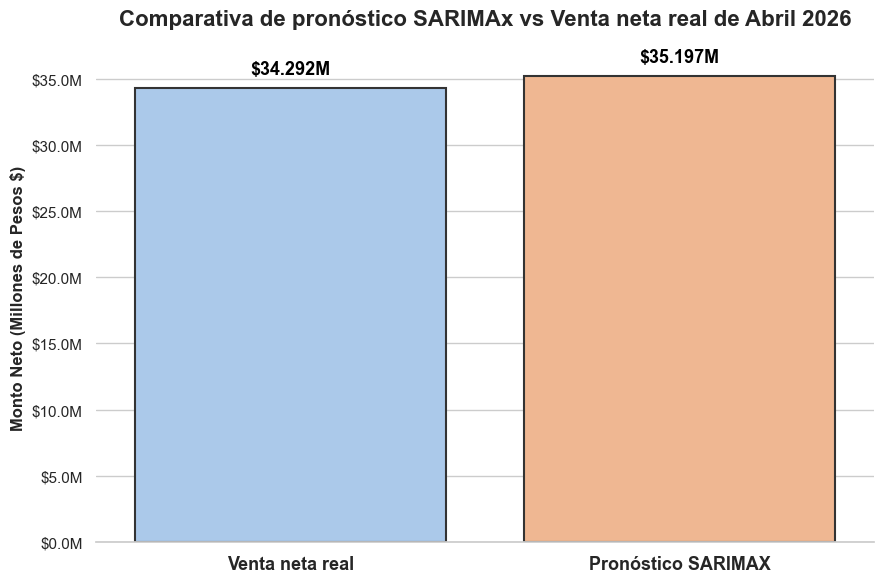

In [52]:
total_real_abril = y_val.sum()
total_pred_abril = pred_val.sum()

df_reporte_abril = pd.DataFrame({
    'Tipo': ['Venta neta real', 'Pronóstico SARIMAX'],
    'Monto ($M)': [total_real_abril, total_pred_abril]
})

sns.set_theme(style="whitegrid", palette="pastel")

plt.figure(figsize=(9, 6), dpi=100)

ax = sns.barplot(
    data=df_reporte_abril,
    x='Tipo', 
    y='Monto ($M)',
    hue='Tipo',
    legend=False,
    edgecolor=".2",
    linewidth=1.5
)


plt.title('Comparativa de pronóstico SARIMAx vs Venta neta real de Abril 2026', 
          fontsize=16, fontweight='bold', pad=20, family='Arial')

plt.xlabel('')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=13, fontweight='bold')

formatter = ticker.StrMethodFormatter('${x:.1f}M')
ax.yaxis.set_major_formatter(formatter)


for p in ax.patches:

    height = p.get_height()

    ax.annotate(f'${height:.3f}M', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 7), 
                textcoords='offset points')

sns.despine(left=True, bottom=False)


plt.tight_layout()

plt.show()

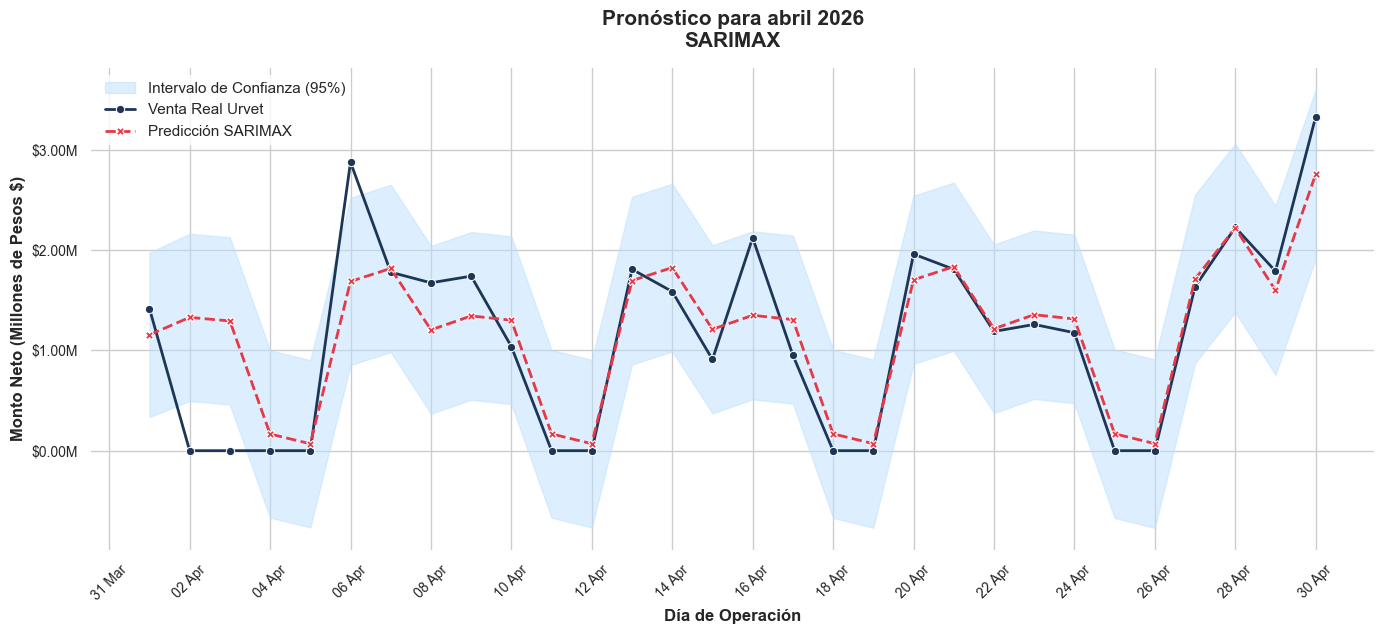

In [19]:
df_ci_completo = forecast_objeto.conf_int(alpha=0.05)

ci_lower_april = df_ci_completo.iloc[:, 0].loc[validation_start:validation_end]
ci_upper_april = df_ci_completo.iloc[:, 1].loc[validation_start:validation_end]


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6.5), dpi=100)

plt.fill_between(
    pred_val.index, 
    ci_lower_april, 
    ci_upper_april, 
    color='#bde0fe', 
    alpha=0.5, 
    label='Intervalo de Confianza (95%)'
)

sns.lineplot(
    x=y_val.index, 
    y=y_val.values, 
    marker='o', 
    markersize=6,
    color='#1d3557', 
    linewidth=2, 
    label='Venta Real Urvet'
)

sns.lineplot(
    x=pred_val.index, 
    y=pred_val.values, 
    marker='X', 
    markersize=6,
    color='#e63946', 
    linewidth=2, 
    linestyle='--', 
    label='Predicción SARIMAX'
)

plt.title('Pronóstico para abril 2026\nSARIMAX', 
          fontsize=15, fontweight='bold', pad=15, family='Arial')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xlabel('Día de Operación', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.2f}M"))
plt.yticks(fontsize=10)

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [20]:
dias_mayo_completo = pd.date_range(start="2026-05-01", end="2026-05-31", freq='D')
X_mayo_completo = pd.DataFrame(index=dias_mayo_completo)

feriados_2026 = ['2026-05-01']
X_mayo_completo['non_work_day'] = X_mayo_completo.index.strftime('%Y-%m-%d').isin(feriados_2026).astype(int)
is_weekend_may = X_mayo_completo.index.weekday.isin([5, 6])
X_mayo_completo['is_workday'] = ~(is_weekend_may | (X_mayo_completo['non_work_day'] == 1))

X_mayo_completo['is_month_end'] = 0
X_mayo_completo['close_month_zone'] = 0

work_days_may = X_mayo_completo[X_mayo_completo['is_workday']].index
if len(work_days_may) >= 1:
    X_mayo_completo.loc[work_days_may[-1], 'is_month_end'] = 1
if len(work_days_may) >= 3:
    X_mayo_completo.loc[work_days_may[-3:-1], 'close_month_zone'] = 1


X_test_extended = X_mayo_completo[['is_month_end', 'close_month_zone']]
X_futuro_total = pd.concat([X_val, X_test_extended])
X_futuro_total = X_futuro_total[['is_month_end', 'close_month_zone']]


forecast_objeto_total = fit_res_3.get_forecast(steps=len(X_futuro_total), exog=X_futuro_total)
pred_futuro_total = forecast_objeto_total.predicted_mean
df_ci_total = forecast_objeto_total.conf_int(alpha=0.05)

pred_test_extended = pred_futuro_total['2026-05-01':'2026-05-31']
ci_lower_may_ext = df_ci_total.iloc[:, 0].loc['2026-05-01':'2026-05-31']
ci_upper_may_ext = df_ci_total.iloc[:, 1].loc['2026-05-01':'2026-05-31']

display(ci_lower_may_ext)
display(ci_upper_may_ext)


2026-05-01    0.47791887
2026-05-02   -0.67254627
2026-05-03   -0.77154642
2026-05-04    0.87841868
2026-05-05    1.01027608
2026-05-06    0.38391495
2026-05-07    0.52520086
2026-05-08    0.48210869
2026-05-09   -0.67374526
2026-05-10   -0.77320913
2026-05-11    0.88448444
2026-05-12    1.01695946
2026-05-13    0.38765998
2026-05-14    0.52960754
2026-05-15    0.48631351
2026-05-16   -0.67495449
2026-05-17   -0.77488425
2026-05-18    0.89057400
2026-05-19    1.02366954
2026-05-20    0.39141793
2026-05-21    0.53403022
2026-05-22    0.49053340
2026-05-23   -0.67617400
2026-05-24   -0.77657184
2026-05-25    0.89668746
2026-05-26    1.03040642
2026-05-27    0.77314487
2026-05-28    0.91642501
2026-05-29    1.89017232
2026-05-30   -0.67740387
2026-05-31   -0.77827197
Freq: D, Name: lower net_price, dtype: float64

2026-05-01   2.16211213
2026-05-02   1.01164713
2026-05-03   0.91264698
2026-05-04   2.56261208
2026-05-05   2.69446948
2026-05-06   2.07196272
2026-05-07   2.21337623
2026-05-08   2.17028828
2026-05-09   1.01443447
2026-05-10   0.91497061
2026-05-11   2.57266418
2026-05-12   2.70513920
2026-05-13   2.07972107
2026-05-14   2.22179712
2026-05-15   2.17850735
2026-05-16   1.01723949
2026-05-17   0.91730974
2026-05-18   2.58276798
2026-05-19   2.71586352
2026-05-20   2.08752039
2026-05-21   2.23026207
2026-05-22   2.18676954
2026-05-23   1.02006228
2026-05-24   0.91966445
2026-05-25   2.59292374
2026-05-26   2.72664271
2026-05-27   2.47331692
2026-05-28   2.61672735
2026-05-29   3.59047898
2026-05-30   1.02290293
2026-05-31   0.92203483
Freq: D, Name: upper net_price, dtype: float64

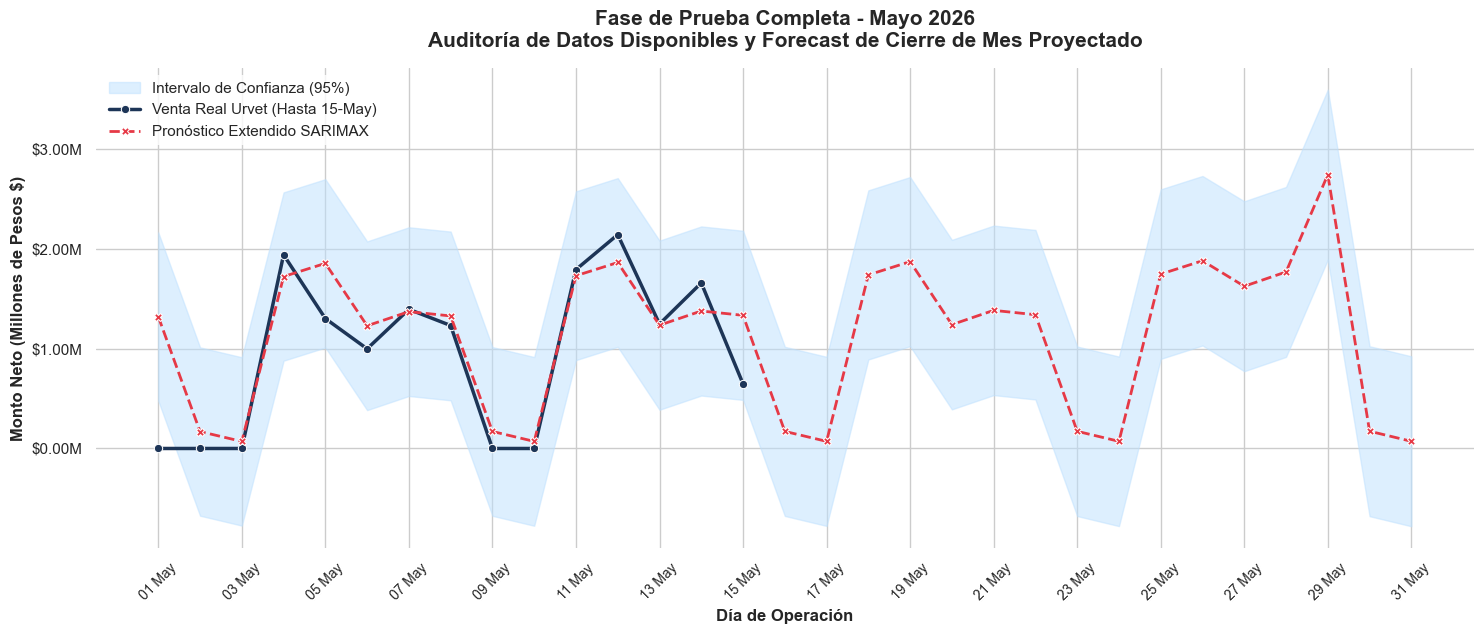

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6.5), dpi=100)


plt.fill_between(
    pred_test_extended.index, 
    ci_lower_may_ext, 
    ci_upper_may_ext, 
    color='#bde0fe', 
    alpha=0.5, 
    label='Intervalo de Confianza (95%)'
)

sns.lineplot(
    x=y_test.index, 
    y=y_test.values, 
    marker='o', 
    markersize=6,
    color='#1d3557', 
    linewidth=2.5, 
    label='Venta Real Urvet (Hasta 15-May)'
)

sns.lineplot(
    x=pred_test_extended.index, 
    y=pred_test_extended.values, 
    marker='X', 
    markersize=6,
    color='#e63946', 
    linewidth=2, 
    linestyle='--', 
    label='Pronóstico Extendido SARIMAX'
)
plt.title('Fase de Prueba Completa - Mayo 2026\nAuditoría de Datos Disponibles y Forecast de Cierre de Mes Proyectado', 
          fontsize=15, fontweight='bold', pad=15, family='Arial')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xlabel('Día de Operación', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, fontsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.2f}M"))
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=11)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

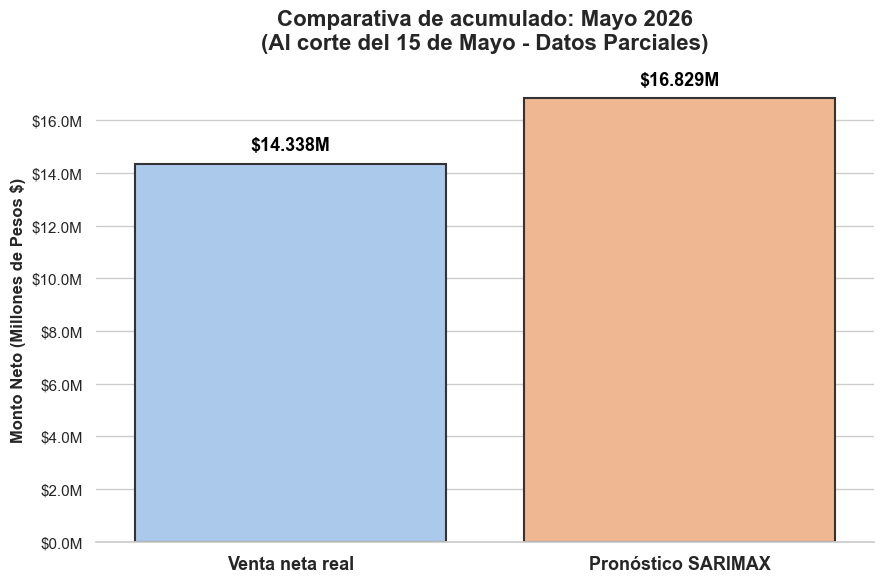

In [22]:
total_real_mayo_parcial = y_test.sum()

total_pred_mayo_parcial = pred_test_extended.loc[y_test.index].sum()

df_reporte_mayo = pd.DataFrame({
    'Tipo': ['Venta neta real', 'Pronóstico SARIMAX'],
    'Monto ($M)': [total_real_mayo_parcial, total_pred_mayo_parcial]
})

sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(9, 6), dpi=100)

ax = sns.barplot(
    data=df_reporte_mayo,
    x='Tipo', 
    y='Monto ($M)',
    hue='Tipo',
    legend=False,
    edgecolor=".2",
    linewidth=1.5
)

plt.title('Comparativa de acumulado: Mayo 2026\n(Al corte del 15 de Mayo - Datos Parciales)', 
          fontsize=16, fontweight='bold', pad=20, family='Arial')

plt.xlabel('')
plt.ylabel('Monto Neto (Millones de Pesos $)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=13, fontweight='bold')

formatter = ticker.StrMethodFormatter('${x:.1f}M')
ax.yaxis.set_major_formatter(formatter)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:.3f}M', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 7), 
                textcoords='offset points')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()